In [1]:
from anchoring_detection.preprocess import Preprocess

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import svm
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay

## Preprocesamiento. Construcción del set de datos

In [2]:
prepro = Preprocess()

Cargamos los datos de las simulaciones

In [3]:
# FUNCIONA
dataframes_surge, dataframes_sway = prepro.extract_res_files()

In [4]:
dataframes_surge['oc4__Hs1__Tp2__dir1__2']

,time[s],Surge
0,180.0,11.2440
1,180.1,11.2565
2,180.2,11.2689
3,180.3,11.2810
4,180.4,11.2929
...,...,...
10196,1199.6,19.6387
10197,1199.7,19.6433
10198,1199.8,19.6480
10199,1199.9,19.6531


Las señales requieren estabilización en el equilibrio porque se produce ligero hundimiento (por el error cometido en el cálculo manual de Fz de compensación de obra muerta). Con el siguiente método, solventamos este problema y aplicamos fft.

In [5]:
tff = prepro.fourier_python()

In [6]:
dataframes_surge['oc4__Hs2__Tp3__dir1__2']

,Frequencies,Amplitudes
0,0.000000,1.328654e-15
1,0.000980,6.945420e-01
2,0.001961,5.813166e-01
3,0.002941,4.416444e-01
4,0.003921,3.388452e-01
...,...,...
5095,4.994608,3.817992e-04
5096,4.995589,3.816180e-04
5097,4.996569,3.815515e-04
5098,4.997549,3.814842e-04


Determinamos los momentos espectrales de cada simulación

In [16]:
dataset = prepro.moment_python()

In [17]:
dataset

,Hs,Tp,Direction,m0_Surge,m2_Surge,m4_Surge,m0_Sway,m2_Sway,m4_Sway,Dragging
oc4__Hs1__Tp2__dir1__1,1.21,8.15,0,0.002438,0.003567,0.047892,0.001749,0.003374,0.045315,0
oc4__Hs1__Tp2__dir1__2,1.21,8.15,0,0.011784,0.020603,0.276744,0.008595,0.015042,0.202063,1
oc4__Hs1__Tp2__dir2__1,1.21,8.15,60,0.002250,0.003548,0.047649,0.001852,0.002840,0.038124,0
oc4__Hs1__Tp2__dir2__2,1.21,8.15,60,0.011667,0.020584,0.276506,0.008593,0.014508,0.194887,1
oc4__Hs1__Tp2__dir3__1,1.21,8.15,90,0.002209,0.003746,0.050323,0.001888,0.002869,0.038510,0
...,...,...,...,...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,8.10,18.69,90,0.012230,0.020804,0.279441,0.018121,0.027863,0.373985,1
oc4__Hs4__Tp5__dir4__1,8.10,18.69,120,0.005428,0.002837,0.037927,0.010878,0.014440,0.193691,0
oc4__Hs4__Tp5__dir4__2,8.10,18.69,120,0.012206,0.014142,0.189936,0.016706,0.025973,0.348638,1
oc4__Hs4__Tp5__dir5__1,8.10,18.69,180,0.011085,0.009327,0.124935,0.002734,0.003005,0.040322,0


Adjuntamos las etiquetas al dataset

<Axes: >

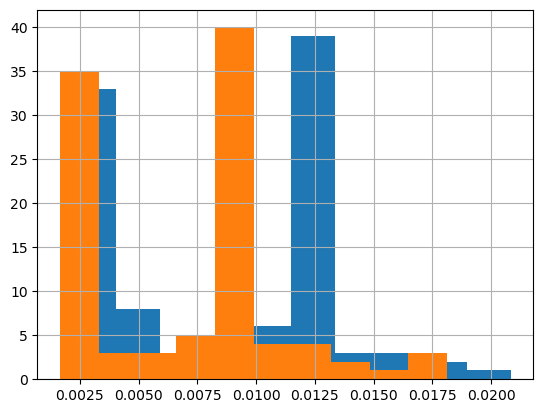

In [18]:
dataset['m0_Surge'].hist()
dataset['m0_Sway'].hist()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


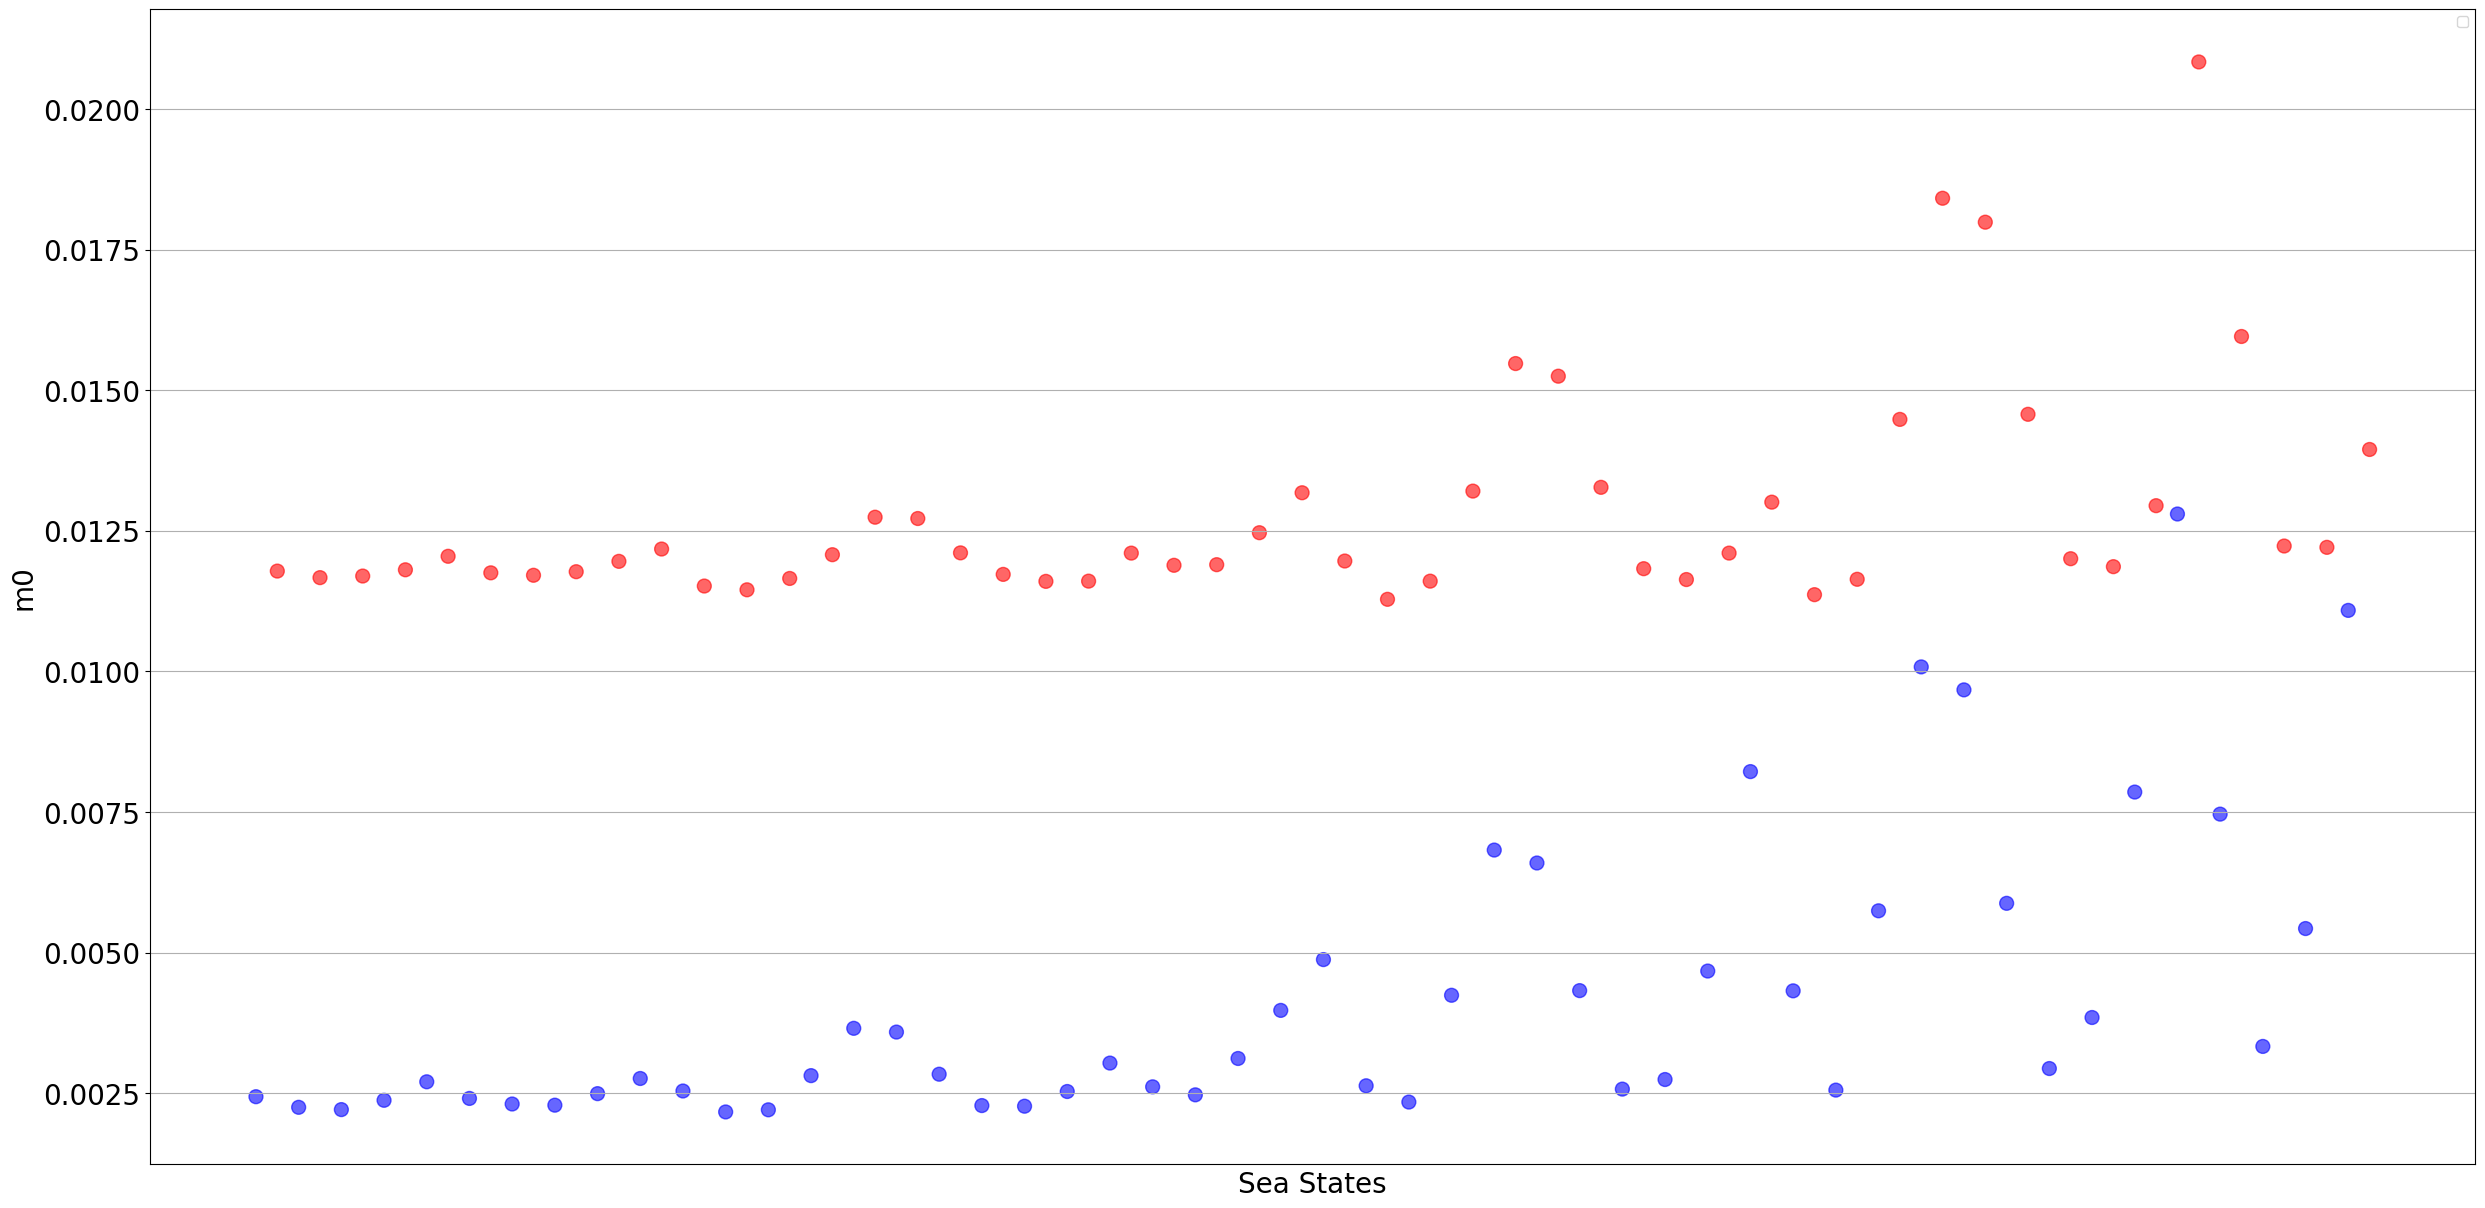

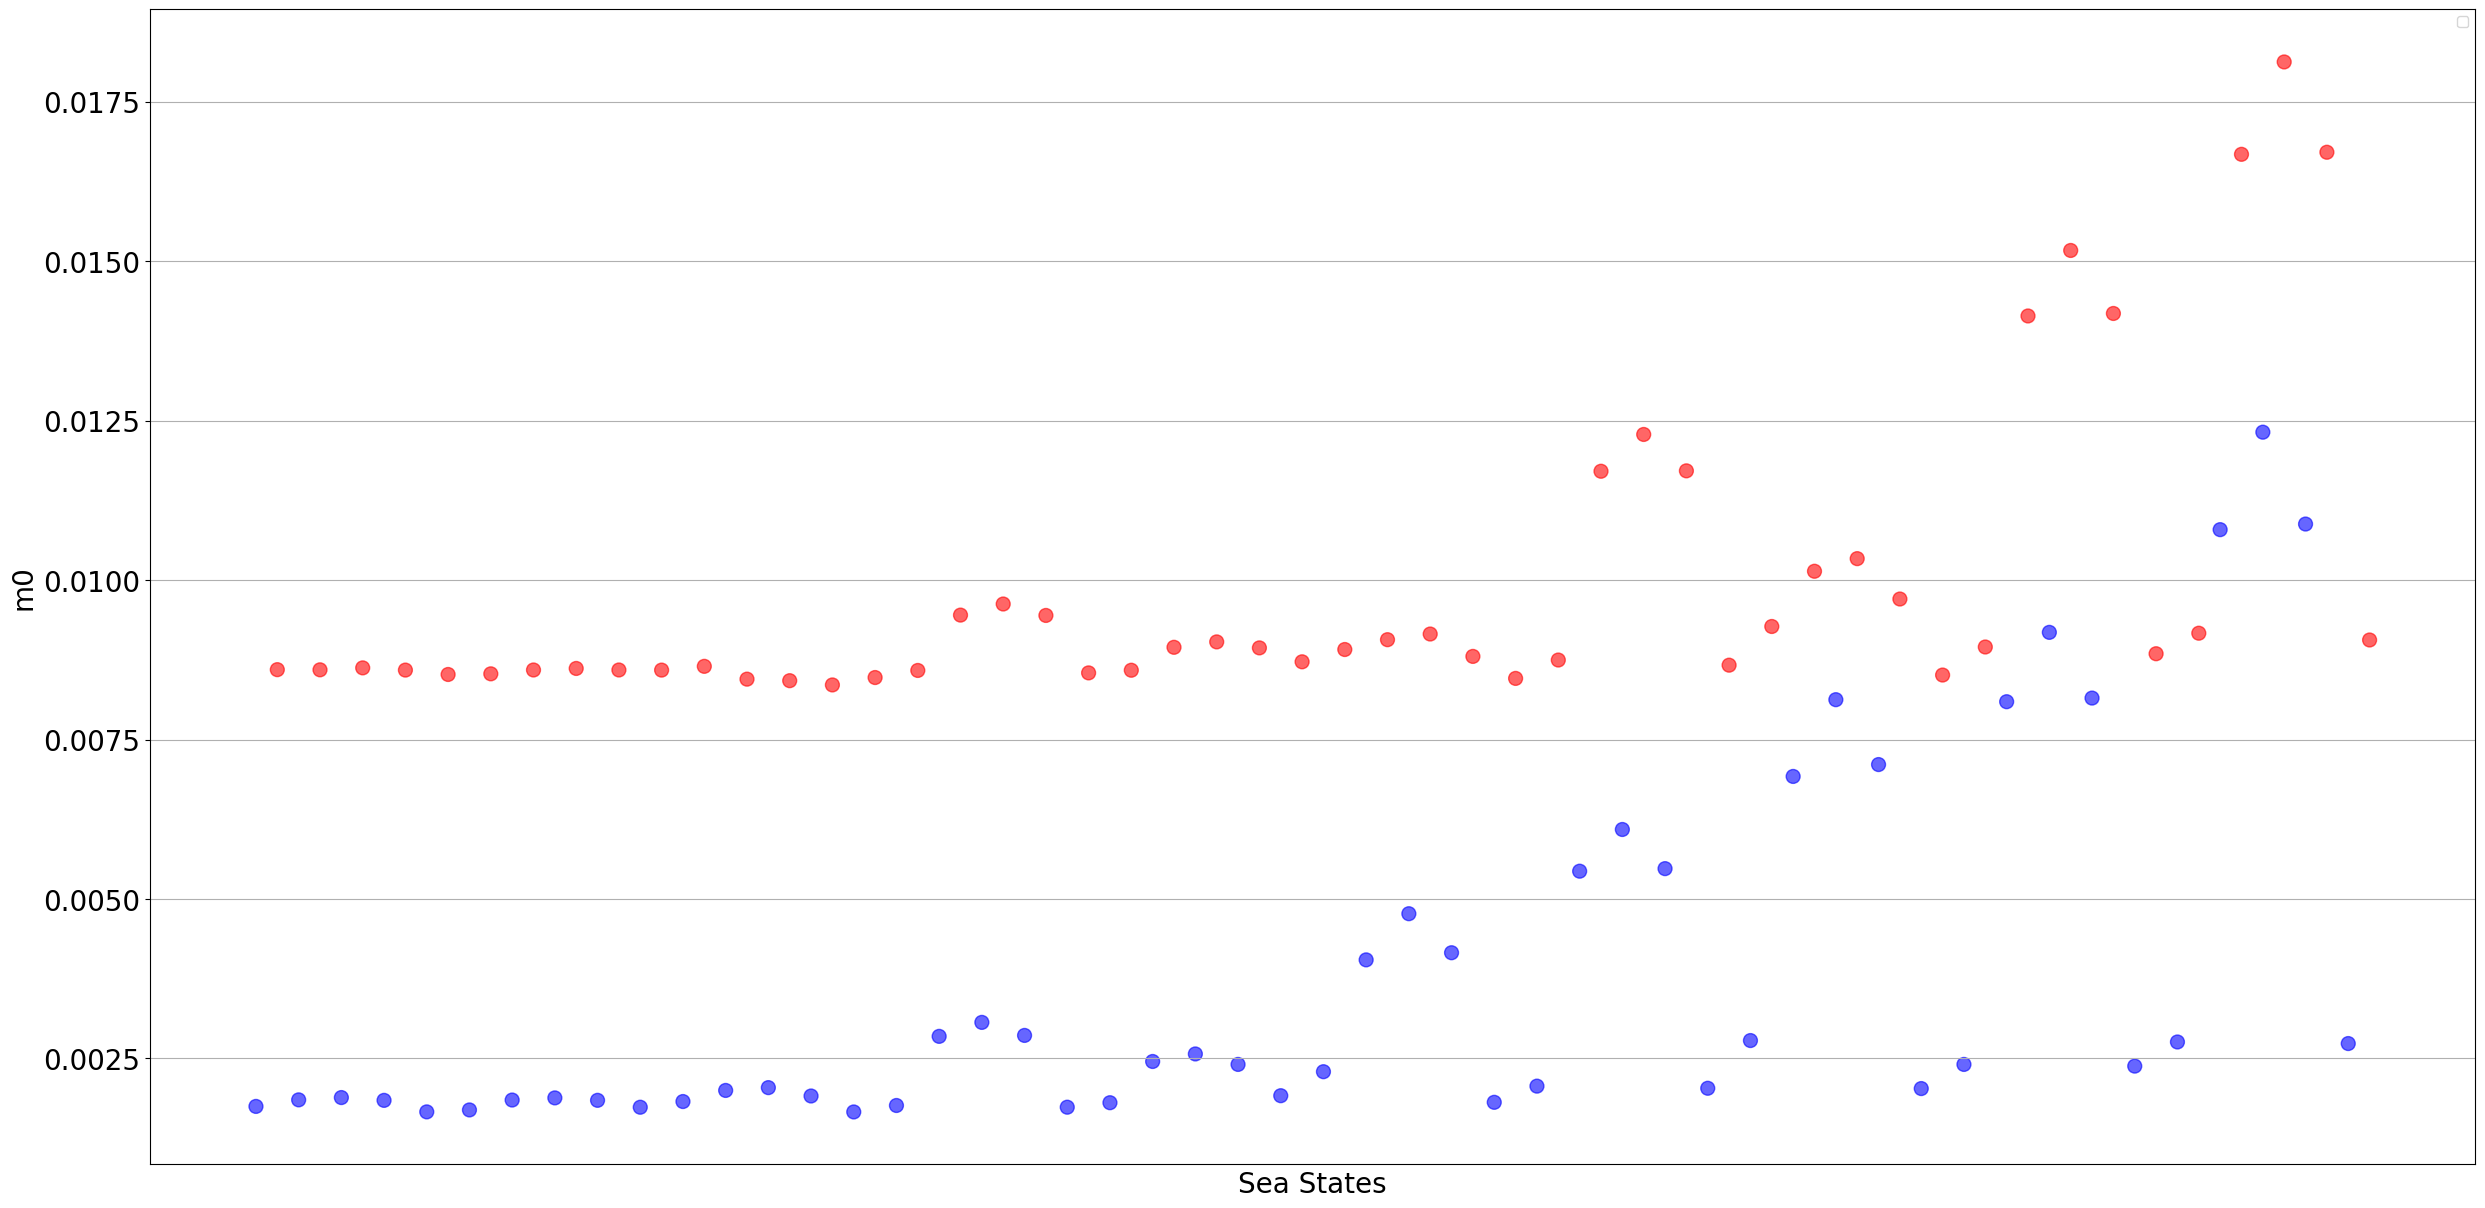

In [37]:
moves = ['Surge','Sway']
for mov in moves:
    plt.figure(figsize=(30,15))
    colors = dataset['Dragging'][0:100].map({1: 'r', 0: 'b'})

    plt.scatter(dataset.index[0:100],dataset[f'm2_{mov}'][0:100],color=colors,alpha=0.6, s=100)

    plt.xlabel('Sea States',fontsize = 20)
    plt.xticks([])
    plt.ylabel('m2',fontsize=20)
    plt.yticks(fontsize=20)
    #plt.title(f"m0_{mov}", fontsize = 18)
    plt.grid()
    plt.legend()

Se requiere dividir los dataframes en datos de train y test, ademas de escalar y normalizar los momentos

In [20]:
#X = dataset[['m0_Surge', 'm2_Surge', 'm4_Surge', 'm0_Sway', 'm2_Sway', 'm4_Sway']]
X = dataset[['m0_Surge','m0_Sway']]
Y = dataset['Dragging']

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [22]:
X_train

,m0_Surge,m0_Sway
oc4__Hs2__Tp4__dir3__2,0.011605,0.009154
oc4__Hs3__Tp5__dir5__1,0.007855,0.002380
oc4__Hs1__Tp4__dir4__1,0.002813,0.001912
oc4__Hs2__Tp3__dir2__1,0.002614,0.002453
oc4__Hs2__Tp5__dir5__2,0.012104,0.008665
...,...,...
oc4__Hs2__Tp5__dir1__1,0.006594,0.002067
oc4__Hs3__Tp4__dir1__2,0.013009,0.009272
oc4__Hs1__Tp3__dir3__1,0.002287,0.001882
oc4__Hs4__Tp5__dir2__1,0.007462,0.010790


In [23]:
min_max_scaler = MinMaxScaler()
X_train_min_max = min_max_scaler.fit_transform(X_train)
X_test_min_max = min_max_scaler.transform(X_test)

In [24]:
X_train_min_max

array([[5.04500640e-01, 4.55158355e-01],
       [3.03228249e-01, 4.36359741e-02],
       [3.26131792e-02, 1.51920119e-02],
       [2.19380042e-02, 4.80576861e-02],
       [5.31270921e-01, 4.25489346e-01],
       [5.13528602e-01, 4.22374363e-01],
       [4.45846522e-02, 8.79549088e-03],
       [1.72981673e-01, 5.59902401e-01],
       [5.28233938e-01, 4.16633467e-01],
       [1.13535170e-01, 3.19524879e-01],
       [5.12448098e-01, 4.17256043e-01],
       [5.50741447e-01, 4.41963946e-01],
       [5.25921438e-01, 8.20456289e-01],
       [7.77665957e-02, 0.00000000e+00],
       [7.37998488e-01, 9.12025038e-01],
       [5.09386073e-01, 4.22926047e-01],
       [2.89048100e-02, 2.31721707e-01],
       [5.16402185e-01, 6.45224692e-01],
       [5.10958037e-01, 4.83749688e-01],
       [1.54215944e-02, 1.10629605e-02],
       [5.88874676e-01, 4.28713567e-01],
       [4.04885713e-03, 8.52896157e-02],
       [5.15357644e-01, 4.20816377e-01],
       [5.38037737e-01, 1.00000000e+00],
       [5.297561

In [25]:
X_test_min_max

array([[ 6.63733468e-01,  7.58073966e-01],
       [ 4.87173885e-01,  4.49767435e-01],
       [ 3.22760367e-01,  6.79966552e-02],
       [ 5.20230823e-01,  4.47677483e-01],
       [ 1.42889728e-02,  5.52338829e-02],
       [ 5.04519910e-01,  4.18150844e-01],
       [-2.04055519e-03,  2.04837467e-02],
       [ 4.00758713e-01,  4.52471499e-02],
       [ 1.08575442e-02,  1.91338564e-03],
       [ 1.25044611e-02,  5.26385283e-03],
       [ 2.98893951e-02,  4.48592072e-03],
       [ 7.41840630e-02,  6.14907855e-03],
       [ 4.91613222e-01,  5.14942585e-01],
       [ 5.31501789e-01,  4.73184436e-01],
       [ 5.68578939e-01,  6.66354396e-02],
       [ 1.97387503e-04,  1.37018451e-02],
       [ 1.89916167e-01,  3.30847001e-01],
       [ 6.58873309e-01,  4.88498490e-01],
       [ 5.53890124e-03,  1.13371423e-02],
       [ 5.64287453e-01,  4.20466626e-01]])

## Modelos

### SVM

In [26]:
svm_clf = svm.SVC()

In [27]:
svm_clf.fit(X_train_min_max,Y_train)

SVC()

#### Validación cruzada del entrenamiento

In [28]:
cross_val_score(svm_clf, X_train_min_max, Y_train, cv=5,scoring='accuracy')

array([1., 1., 1., 1., 1.])

In [29]:
y_validate_pred = cross_val_predict(svm_clf, X_train_min_max, Y_train, cv=5)
y_validate_pred

array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1], dtype=int64)

In [30]:
acu_svc = metrics.accuracy_score(Y_train,y_validate_pred)
precision_svc = metrics.precision_score(Y_train,y_validate_pred)
recall_svc = metrics.recall_score(Y_train,y_validate_pred)
f1_svc = metrics.f1_score(Y_train,y_validate_pred)

print(f"% ACURACCY --> {acu_svc*100} %")
print(f"% PRECISION --> {precision_svc*100} %")
print(f"% RECALL --> {recall_svc*100} %")
print(f"% f1 --> {f1_svc*100} %")

% ACURACCY --> 100.0 %
% PRECISION --> 100.0 %
% RECALL --> 100.0 %
% f1 --> 100.0 %


In [31]:
cm_svc = metrics.confusion_matrix(Y_train,y_validate_pred)
cm_svc

array([[38,  0],
       [ 0, 42]], dtype=int64)

Matriz confusión con datos de validación

Text(0.5, 1.0, 'Matriz de Confusión. SVM')

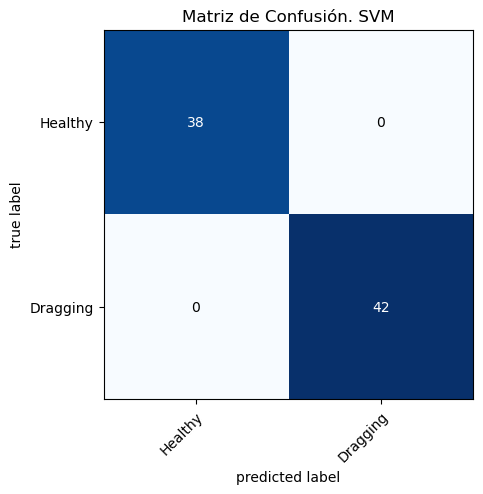

In [32]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm_svc,class_names=dragging)
plt.title('Matriz de Confusión. SVM')

In [33]:
medias_por_vector = np.mean(X_train_min_max, axis=1)

Text(0.5, 1.0, 'Compare train status with m0 mean')

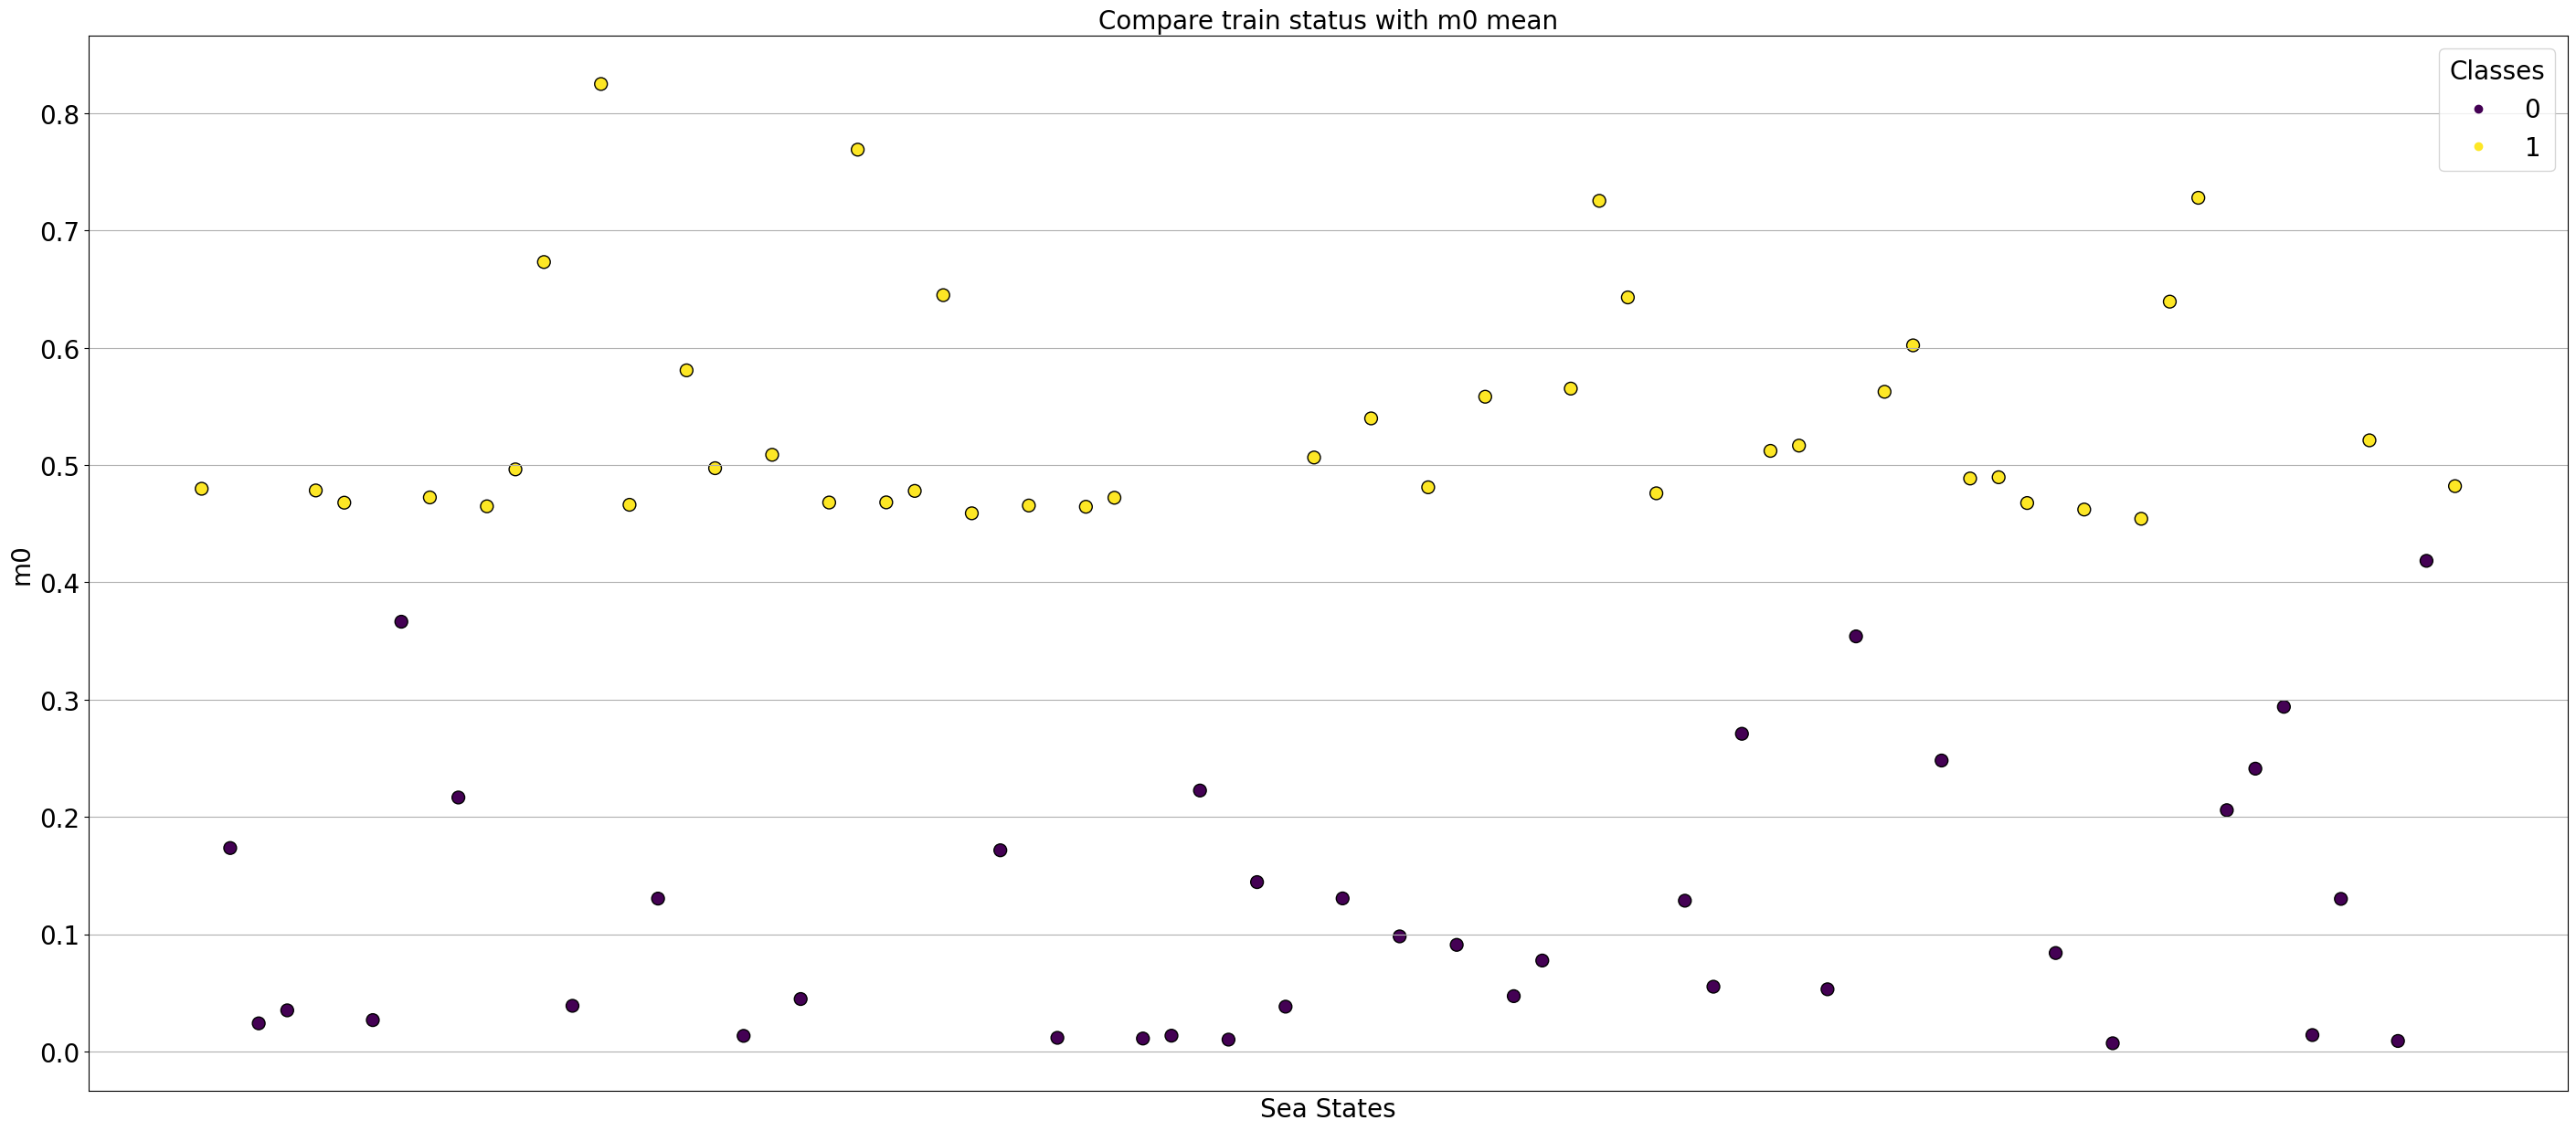

In [34]:
plt.figure(figsize=(35,15))
scat0 = plt.scatter(Y_train.index,medias_por_vector,c=Y_train, label=Y_train, edgecolors="k",s=100)
plt.xlabel('Sea States', fontsize = 20)
plt.ylabel('m0',fontsize = 20)
plt.grid()
plt.xticks([])
plt.yticks(fontsize=20)
plt.legend(*scat0.legend_elements(),loc="upper right", title="Classes", fontsize = 20,  title_fontsize=20)
plt.title("Compare train status with m0 mean",fontsize=20)

#### Hiperparametros

In [51]:
param_grid = [
    {'C':[1, 10, 100, 1000],'kernel':['linear']},
    {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
    {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['sigmoid']}
]

grid_search = GridSearchCV(svm_clf, param_grid, cv=5, scoring= ['accuracy','precision','recall','f1'],refit='recall', return_train_score=True)

grid_search.fit(X_train_min_max,Y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']},
                         {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['sigmoid']}],
             refit='recall', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1'])

In [52]:
hyperparams = pd.DataFrame(grid_search.cv_results_)
metric_columns = ['param_C', 'param_gamma', 'param_kernel', 'mean_train_accuracy', 'mean_train_precision', 'mean_train_recall', 'mean_train_f1']
hyperparams = hyperparams[metric_columns]

hyperparams

,param_C,param_gamma,param_kernel,mean_train_accuracy,mean_train_precision,mean_train_recall,mean_train_f1
0,1,NaN,linear,0.822898,0.884753,0.807053,0.844072
1,10,NaN,linear,0.825530,0.893160,0.802705,0.845242
2,100,NaN,linear,0.822932,0.888544,0.802705,0.843272
3,1000,NaN,linear,0.825530,0.892842,0.802705,0.845250
4,1,0.001,rbf,0.593746,0.593746,1.000000,0.745082
5,1,0.0001,rbf,0.593746,0.593746,1.000000,0.745082
6,10,0.001,rbf,0.593746,0.593746,1.000000,0.745082
7,10,0.0001,rbf,0.593746,0.593746,1.000000,0.745082
8,100,0.001,rbf,0.796856,0.824970,0.837585,0.830551
9,100,0.0001,rbf,0.593746,0.593746,1.000000,0.745082


In [53]:
print(f'BEST ESTIMATOR --> {grid_search.best_params_}')

BEST ESTIMATOR --> {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}


#### Entrenamiento con hiperparámetros

In [54]:
svm_clf = svm.SVC(C=1, kernel='linear')

In [55]:
svm_clf.fit(X_train_min_max,Y_train)

SVC(C=1, kernel='linear')

In [56]:
cross_val_score(svm_clf, X_train_min_max, Y_train, cv=5,scoring='accuracy')

array([0.85      , 0.89473684, 0.73684211, 0.78947368, 0.78947368])

In [57]:
y_validate_pred = cross_val_predict(svm_clf, X_train_min_max, Y_train, cv=5)

In [58]:
acu_svc = metrics.accuracy_score(Y_train,y_validate_pred)
precision_svc = metrics.precision_score(Y_train,y_validate_pred)
recall_svc = metrics.recall_score(Y_train,y_validate_pred)
f1_svc = metrics.f1_score(Y_train,y_validate_pred)

print(f"% ACURACCY --> {acu_svc*100} %")
print(f"% PRECISION --> {precision_svc*100} %")
print(f"% RECALL --> {recall_svc*100} %")
print(f"% f1 --> {f1_svc*100} %")

% ACURACCY --> 81.25 %
% PRECISION --> 86.79245283018868 %
% RECALL --> 80.7017543859649 %
% f1 --> 83.63636363636363 %


In [59]:
cm_svc_train = metrics.confusion_matrix(Y_train,y_validate_pred)
cm_svc_train

array([[32,  7],
       [11, 46]], dtype=int64)

Text(0.5, 1.0, 'Matriz de Confusión. SVM con hiperparámetros')

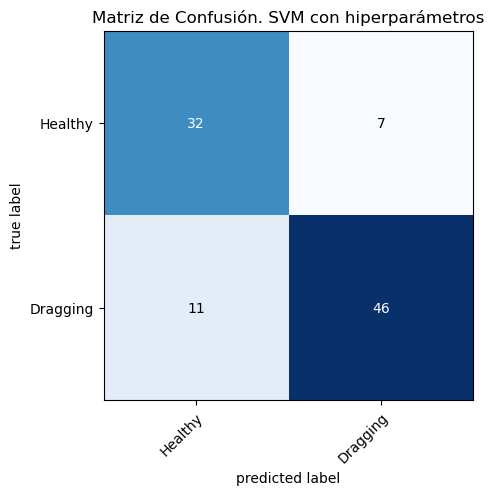

In [60]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm_svc_train,class_names=dragging)
plt.title('Matriz de Confusión. SVM con hiperparámetros')

#### Predicciones con datos nuevos

In [61]:
Y_pred_test = svm_clf.predict(X_test_min_max)

In [62]:
acu_svc = metrics.accuracy_score(Y_test,Y_pred_test)
precision_svc = metrics.precision_score(Y_test,Y_pred_test)
recall_svc = metrics.recall_score(Y_test,Y_pred_test)
f1_svc = metrics.f1_score(Y_test,Y_pred_test)

print(f"% ACURACCY --> {acu_svc*100} %")
print(f"% PRECISION --> {precision_svc*100} %")
print(f"% RECALL --> {recall_svc*100} %")
print(f"% f1 --> {f1_svc*100} %")

% ACURACCY --> 91.66666666666666 %
% PRECISION --> 100.0 %
% RECALL --> 84.61538461538461 %
% f1 --> 91.66666666666666 %


In [63]:
cm_svc_test = metrics.confusion_matrix(Y_test,Y_pred_test)
cm_svc_test

array([[11,  0],
       [ 2, 11]], dtype=int64)

Text(0.5, 1.0, 'Matriz de Confusión. SVM con datos TEST')

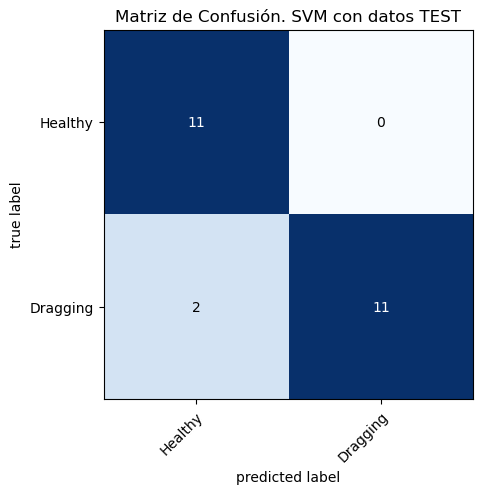

In [65]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm_svc_test,class_names=dragging)
plt.title('Matriz de Confusión. SVM con datos TEST')

Representación del hiperplano obtenido

In [ ]:
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay

# we create 40 separable points
X, y = make_blobs(n_samples=40, centers=2, random_state=6)

# fit the model, don't regularize for illustration purposes
clf = svm.SVC(kernel="linear", C=1000)
clf.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

# plot the decision function
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    plot_method="contour",
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
    ax=ax,
)
# plot support vectors
ax.scatter(
    clf.support_vectors_[:, 0],
    clf.support_vectors_[:, 1],
    s=100,
    linewidth=1,
    facecolors="none",
    edgecolors="k",
)
plt.show()

### Logistic regression

In [20]:
log_clf = LogisticRegression()

In [21]:
log_clf.fit(X_train_min_max,Y_train)

LogisticRegression()

#### Validación Cruzada del entrenamiento

In [22]:
cross_val_score(log_clf, X_train_min_max, Y_train, cv=5,scoring='accuracy')

array([0.8       , 0.89473684, 0.78947368, 0.78947368, 0.73684211])

In [23]:
y_validate_pred = cross_val_predict(log_clf, X_train_min_max, Y_train, cv=5)
y_validate_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0], dtype=int64)

In [24]:
acu_log = metrics.accuracy_score(Y_train,y_validate_pred)
precision_log = metrics.precision_score(Y_train,y_validate_pred)
recall_log = metrics.recall_score(Y_train,y_validate_pred)
f1_log = metrics.f1_score(Y_train,y_validate_pred)

print(f"% ACURACCY --> {acu_log*100} %")
print(f"% PRECISION --> {precision_log*100} %")
print(f"% RECALL --> {recall_log*100} %")
print(f"% f1 --> {f1_log*100} %")

% ACURACCY --> 80.20833333333334 %
% PRECISION --> 82.75862068965517 %
% RECALL --> 84.21052631578947 %
% f1 --> 83.47826086956522 %


In [25]:
cm_log = metrics.confusion_matrix(Y_train,y_validate_pred)
cm_log

array([[29, 10],
       [ 9, 48]], dtype=int64)

Text(0.5, 1.0, 'Matriz de Confusión. REGRESIÓN LOGÍSTICA')

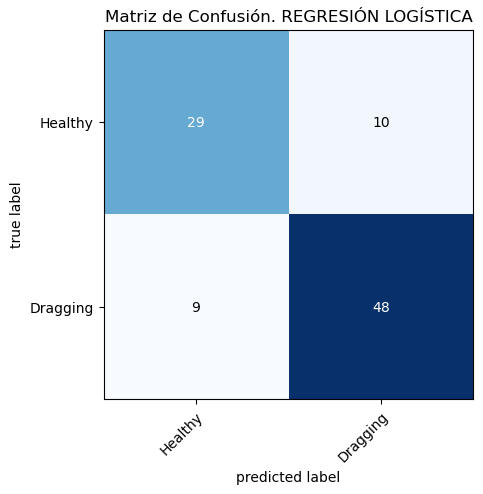

In [26]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm_log,class_names=dragging)
plt.title('Matriz de Confusión. REGRESIÓN LOGÍSTICA')

#### Hiperparámetros

In [27]:
param_grid = [
    {'C':[1, 10, 50, 100],'penalty':['l1','l2'],'solver':['liblinear']}
    ]

grid_search = GridSearchCV(log_clf, param_grid,  cv=5, scoring= ['accuracy','precision','recall','f1'],refit='accuracy', return_train_score=True)

grid_search.fit(X_train_min_max,Y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid=[{'C': [1, 10, 50, 100], 'penalty': ['l1', 'l2'],
                          'solver': ['liblinear']}],
             refit='accuracy', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1'])

In [28]:
hyperparams_log = pd.DataFrame(grid_search.cv_results_)
metric_columns_log = ['param_C', 'param_penalty', 'param_solver', 'mean_train_accuracy', 'mean_train_precision', 'mean_train_recall', 'mean_train_f1']
hyperparams_log = hyperparams_log[metric_columns_log]

hyperparams_log

,param_C,param_penalty,param_solver,mean_train_accuracy,mean_train_precision,mean_train_recall,mean_train_f1
0,1,l1,liblinear,0.807211,0.841713,0.833333,0.837309
1,1,l2,liblinear,0.807280,0.813484,0.877198,0.843873
2,10,l1,liblinear,0.796890,0.835178,0.820193,0.827560
3,10,l2,liblinear,0.794293,0.831339,0.820193,0.825704
4,50,l1,liblinear,0.802085,0.842688,0.820193,0.831232
5,50,l2,liblinear,0.796890,0.835178,0.820193,0.827560
6,100,l1,liblinear,0.802085,0.842688,0.820193,0.831232
7,100,l2,liblinear,0.799487,0.838849,0.820193,0.829376


In [29]:
print(f'BEST PARAMS --> {grid_search.best_params_}')
print(f'BEST ESTIMATOR --> {grid_search.best_estimator_}')

BEST PARAMS --> {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
BEST ESTIMATOR --> LogisticRegression(C=10, penalty='l1', solver='liblinear')


#### Entrenamiento con hiperparámetros

In [30]:
log_clf = LogisticRegression(C=1, penalty='l2',solver='liblinear')

In [31]:
log_clf.fit(X_train_min_max,Y_train)

LogisticRegression(C=1, solver='liblinear')

In [32]:
cross_val_score(log_clf, X_train_min_max, Y_train, cv=5,scoring='accuracy')

array([0.8       , 0.89473684, 0.78947368, 0.78947368, 0.68421053])

In [33]:
y_validate_pred = cross_val_predict(log_clf, X_train_min_max, Y_train, cv=5)

In [34]:
acu_log = metrics.accuracy_score(Y_train,y_validate_pred)
precision_log = metrics.precision_score(Y_train,y_validate_pred)
recall_log = metrics.recall_score(Y_train,y_validate_pred)
f1_log = metrics.f1_score(Y_train,y_validate_pred)

print(f"% ACURACCY --> {acu_log*100} %")
print(f"% PRECISION --> {precision_log*100} %")
print(f"% RECALL --> {recall_log*100} %")
print(f"% f1 --> {f1_log*100} %")

% ACURACCY --> 79.16666666666666 %
% PRECISION --> 81.35593220338984 %
% RECALL --> 84.21052631578947 %
% f1 --> 82.75862068965517 %


In [35]:
cm_log = metrics.confusion_matrix(Y_train,y_validate_pred)
cm_log

array([[28, 11],
       [ 9, 48]], dtype=int64)

Text(0.5, 1.0, 'Matriz de Confusión. REGRESIÓN LOGÍSTICA con hiperparámetros')

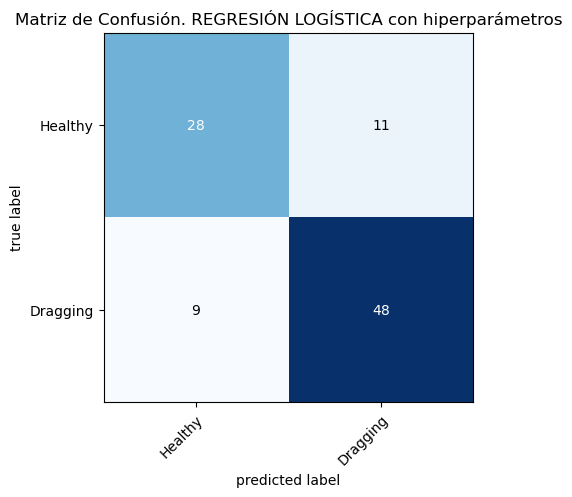

In [36]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm_log,class_names=dragging)
plt.title('Matriz de Confusión. REGRESIÓN LOGÍSTICA con hiperparámetros')

#### Predicciones con datos nuevos

In [37]:
Y_pred_test = log_clf.predict(X_test_min_max)

In [38]:
acu_log = metrics.accuracy_score(Y_test,Y_pred_test)
precision_log = metrics.precision_score(Y_test,Y_pred_test)
recall_log = metrics.recall_score(Y_test,Y_pred_test)
f1_log = metrics.f1_score(Y_test,Y_pred_test)

print(f"% ACURACCY --> {acu_log*100} %")
print(f"% PRECISION --> {precision_log*100} %")
print(f"% RECALL --> {recall_log*100} %")
print(f"% f1 --> {f1_log*100} %")

% ACURACCY --> 95.83333333333334 %
% PRECISION --> 100.0 %
% RECALL --> 92.3076923076923 %
% f1 --> 96.0 %


In [39]:
cm_svc_test = metrics.confusion_matrix(Y_test,Y_pred_test)
cm_svc_test

array([[11,  0],
       [ 1, 12]], dtype=int64)

Text(0.5, 1.0, 'Matriz de Confusión. REGRESIÓN LOGÍSTICA con datos TEST')

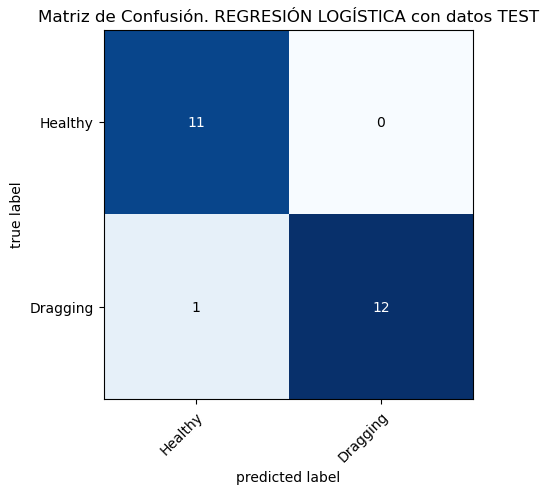

In [41]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm_svc_test,class_names=dragging)
plt.title('Matriz de Confusión. REGRESIÓN LOGÍSTICA con datos TEST')